In [1]:
from utils_dino_final import *
import onnxruntime
import time

def get_onnx_mask_from_bboxes(bboxes, ort_session):

    onnx_coord = np.concatenate([xyxy.reshape(1,2,2) for xyxy in bboxes], axis=0)#[None, :, :]
    onnx_label = np.concatenate([np.array([2,3]).reshape(1,2) for _ in range(bboxes.shape[0])], axis=0).astype(np.float32) #[None, :].astype(np.float32)

    print(onnx_coord.shape)
    print(onnx_label.shape)

    print(image.shape[:2])

    onnx_coord = predictor.transform.apply_coords(onnx_coord, image.shape[:2]).astype(np.float32)

    onnx_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
    onnx_has_mask_input = np.zeros(1, dtype=np.float32)

    ort_inputs = {
        "image_embeddings": image_embedding,
        "point_coords": onnx_coord,
        "point_labels": onnx_label,
        "mask_input": onnx_mask_input,
        "has_mask_input": onnx_has_mask_input,
        "orig_im_size": np.array(image.shape[:2], dtype=np.float32)
    }

    masks, _, _ = ort_session.run(None, ort_inputs)
    masks = masks > predictor.model.mask_threshold
    print(masks.shape)

    return masks

final text_encoder_type: bert-base-uncased


Getting wall mask from  D:\3d-recon\datasets\ASARoomImage\test\input.jpg


wall_bboxes [[1.2349213e+01 2.6789215e+01 8.7199890e+02 7.1330847e+02]
 [8.5554626e+02 1.8173920e+01 1.5023424e+03 8.0649341e+02]
 [7.3563004e-01 1.5610657e+00 1.1011426e+02 9.9001611e+02]
 [1.1037593e+03 5.4701660e+02 1.5028008e+03 8.1097925e+02]]
wall_selected_points [[426, 368], [940, 427], [36, 644], [1314, 672]]
RUG:  0
There is overlap
Subtract rug from floor area NOT OK. Revert to original Floor!
floor_bboxes [[  80.14337  618.74023 1502.8833   990.3489 ]]
floor_selected_points [[727, 735]]
rug_bboxes []
rug_to_floor_indices []
DONE GETTING BBOXES 3.199470043182373
(992, 1504, 3)
DONE SAM EMBEDDING 8.100633144378662
(4, 2, 2)
(4, 2)
(992, 1504)
(4, 1, 992, 1504)
(1, 2, 2)
(1, 2)
(992, 1504)
(1, 1, 992, 1504)
(1, 992, 1504)
(1, 992, 1504)
(1, 992, 1504)
(1, 992, 1504)
[[727 735]]


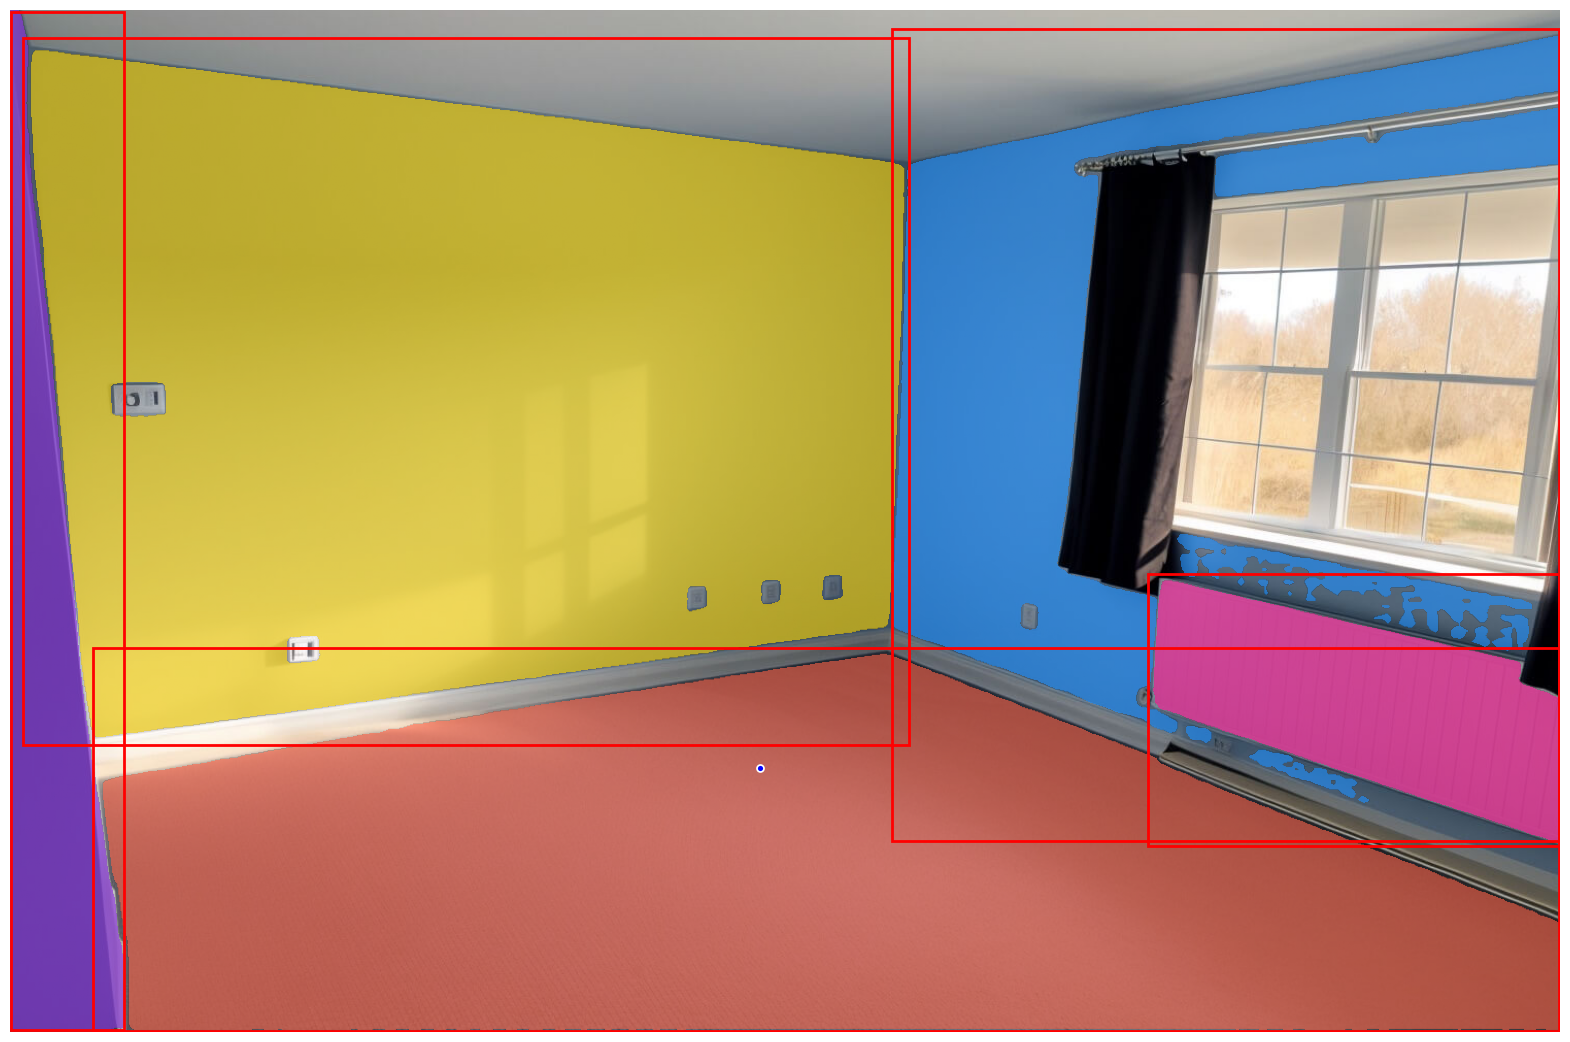

Getting wall mask from  D:\3d-recon\datasets\ASARoomImage\test\Living.JPG


wall_bboxes [[1.4415204e+03 1.2642212e+00 1.9983500e+03 1.1572246e+03]
 [4.0739505e+02 1.5518597e+02 4.7373422e+02 8.9524603e+02]]
wall_selected_points [[1771, 454], [435, 524]]
RUG:  0
No overlap
RUG BBOX 233.61035 877.85895 1797.8077 1186.2987
FLOOR BBOX 0.9227294921875 871.116943359375 1998.9566650390625 1332.5263671875
YES bbox is inside Floor area
floor_bboxes [[1.9227295e+00 8.7211694e+02 1.9979567e+03 1.3315264e+03]]
floor_selected_points [[780, 1318]]
rug_bboxes [[ 233.61035  877.85895 1797.8077  1186.2987 ]]
rug_to_floor_indices [[0]]
DONE GETTING BBOXES 14.431829690933228
(1333, 2000, 3)


DONE SAM EMBEDDING 20.254295587539673
(2, 2, 2)
(2, 2)
(1333, 2000)
(2, 1, 1333, 2000)
(1, 2, 2)
(1, 2)
(1333, 2000)
(1, 1, 1333, 2000)
(1, 2, 2)
(1, 2)
(1333, 2000)
(1, 1, 1333, 2000)
(1, 1333, 2000)
(1, 1333, 2000)
[[ 780 1318]]


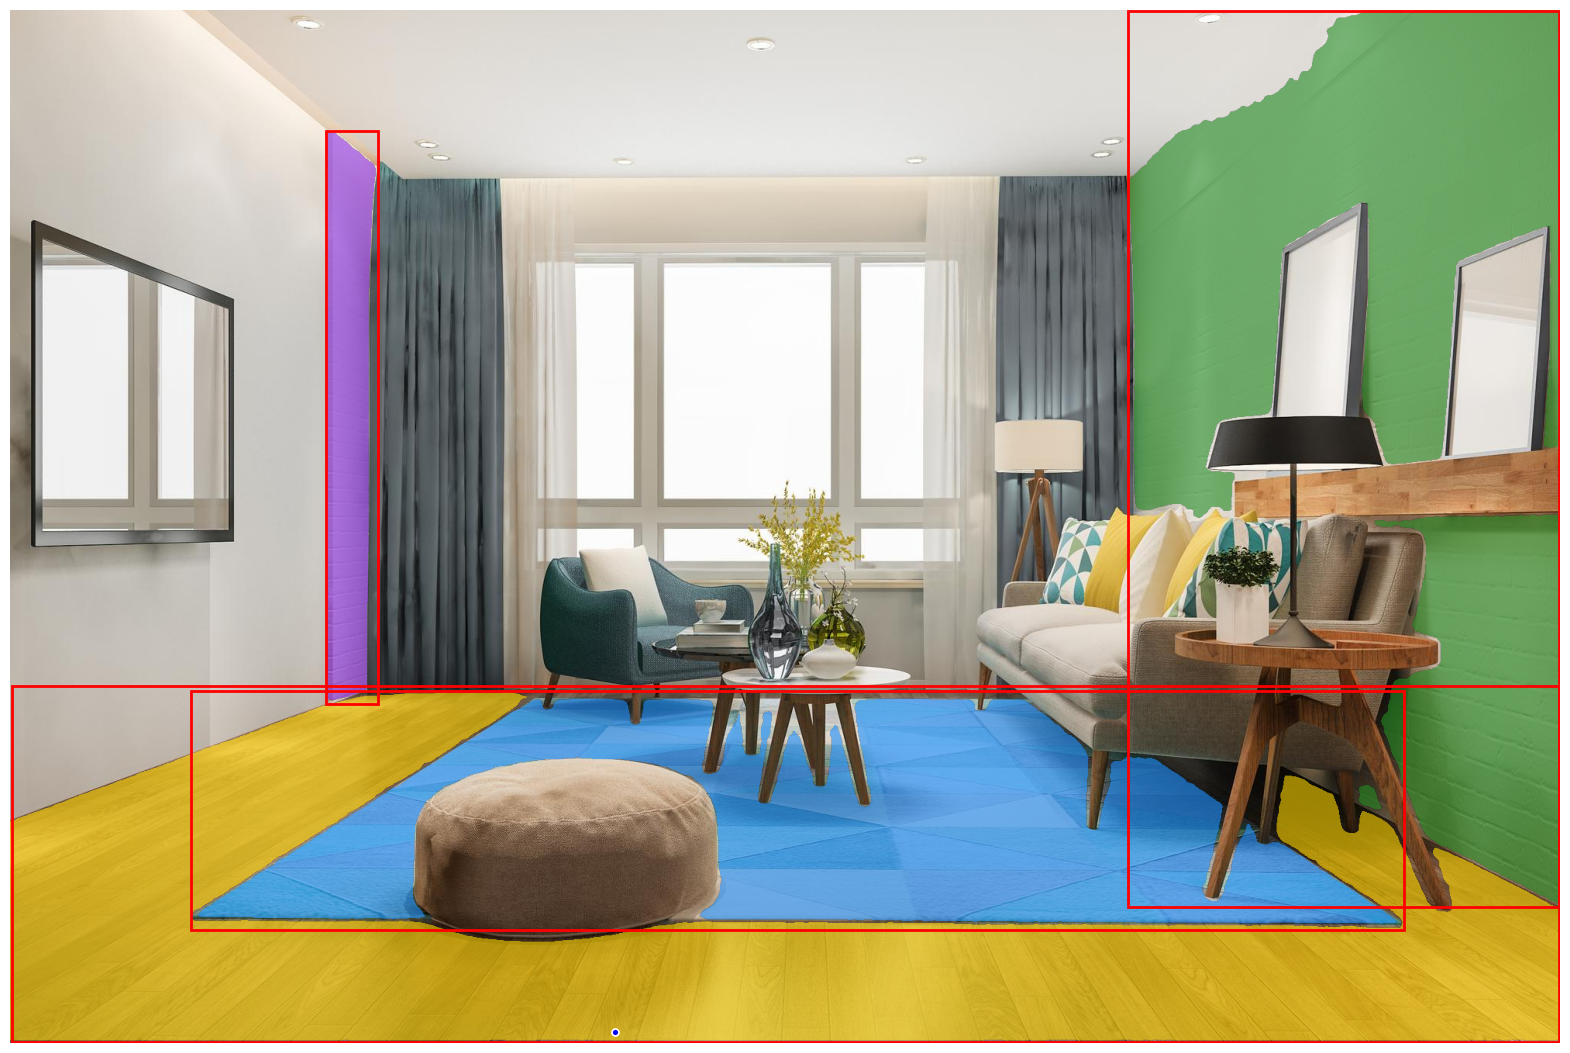

In [2]:
start_time = time.time()

FOLDER_PATH = r"D:\3d-recon\datasets\ASARoomImage"
FOLDER_PATH = r"D:\3d-recon\datasets\ASARoomImage\test"

OUTPUT_FOLDER_PATH = r"D:\3d-recon\Grounded-Segment-Anything\v1_final_output_bbox_onnx_batch"

for IMAGE_NAME in os.listdir(FOLDER_PATH):

  SOURCE_IMAGE_PATH = os.path.join(FOLDER_PATH, IMAGE_NAME)

  wall_bboxes, wall_selected_points = get_wall_bboxes_points(SOURCE_IMAGE_PATH)

  print("wall_bboxes", wall_bboxes)
  print("wall_selected_points", wall_selected_points)

  (floor_bboxes, 
  floor_selected_points, 
  rug_bboxes,
  rug_to_floor_indices) = get_floor_bboxes_points_with_rug(SOURCE_IMAGE_PATH)

  print("floor_bboxes", floor_bboxes)
  print("floor_selected_points", floor_selected_points)

  print("rug_bboxes", rug_bboxes)
  print("rug_to_floor_indices", rug_to_floor_indices)


  output = {'wall_bboxes': wall_bboxes,
        'wall_selected_points':wall_selected_points,
        'floor_bboxes':floor_bboxes,
        'floor_selected_points': floor_selected_points,
        'rug_bboxes': rug_bboxes,
        'rug_to_floor_indices':rug_to_floor_indices}

  print("DONE GETTING BBOXES", time.time()-start_time)



  image = cv2.imread(SOURCE_IMAGE_PATH)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  print(image.shape)

  checkpoint = r"./sam_vit_h_4b8939.pth"

  model_type = "vit_h"
  sam = sam_model_registry[model_type](checkpoint=checkpoint)


  sam.to(device='cuda')
  predictor = SamPredictor(sam)
  predictor.set_image(image)
  image_embedding = predictor.get_image_embedding().cpu().numpy()

  np.save("image_embedding_vith.npy", image_embedding)

  print("DONE SAM EMBEDDING", time.time()-start_time)


  onnx_model_path = "sam_onnx_vith_batch.onnx"
  ort_session = onnxruntime.InferenceSession(onnx_model_path)
  wall_masks = get_onnx_mask_from_bboxes(wall_bboxes, ort_session)

  ort_session = onnxruntime.InferenceSession(onnx_model_path)
  floor_masks = get_onnx_mask_from_bboxes(floor_bboxes, ort_session)

  rug_masks = []
  if len(rug_bboxes)>0:
    ort_session = onnxruntime.InferenceSession(onnx_model_path)
    rug_masks = get_onnx_mask_from_bboxes(rug_bboxes, ort_session)

  # Step 1: Convert to uint8 (0 and 255)
  mask_uint8 = (wall_masks[0].squeeze() * 255).astype(np.uint8)  # shape becomes (2657, 1920)


  plt.figure(figsize=(20,20))
  plt.imshow(image)
  for idx, (mask, bbox, point) in enumerate(zip(wall_masks, wall_bboxes, np.array(wall_selected_points))):
      
      print(mask.shape)
      show_mask(mask, plt.gca())
      show_box(bbox, plt.gca())
      # show_points(np.array([point]), labels=np.array([1]), ax=plt.gca())
      # plt.axis('off')
      # plt.savefig(os.path.join(OUTPUT_FOLDER_PATH,f"wall_{idx}_{IMAGE_NAME}") , bbox_inches='tight', pad_inches=0)
      # plt.show()
  

  # plt.imshow(image)
  for idx, (mask, bbox, point) in enumerate(zip(floor_masks, floor_bboxes, np.array(floor_selected_points))):
      # plt.figure(figsize=(20,20))
      # plt.imshow(image)
      show_mask(mask, plt.gca())
      show_box(bbox, plt.gca())
      show_points(np.array([point]), labels=np.array([1]), ax=plt.gca())
      # plt.axis('off')
      # plt.savefig(os.path.join(OUTPUT_FOLDER_PATH,f"floor_{idx}_{IMAGE_NAME}"), bbox_inches='tight', pad_inches=0)
      # plt.show()
  

  if len(rug_masks)>0:
    # plt.imshow(image)

    for mask, bbox in zip(rug_masks, rug_bboxes):
        show_mask(mask, plt.gca())
        show_box(bbox, plt.gca())
  plt.axis('off')
  plt.savefig(os.path.join(OUTPUT_FOLDER_PATH,f"{IMAGE_NAME}.jpg"))
  plt.show()
